# Task 2 -- K-Means Customer Segmentation
# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Mall_Customers.csv')

In [2]:
# Basic inspection
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())  # check for missing values

(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Inco

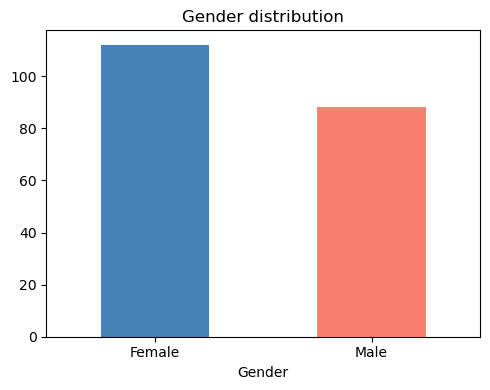

In [5]:
# Rename columns for convenience
df.columns = ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

# Gender distribution
plt.figure(figsize=(5, 4))
df['Gender'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Gender distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_distribution.png')
plt.show()

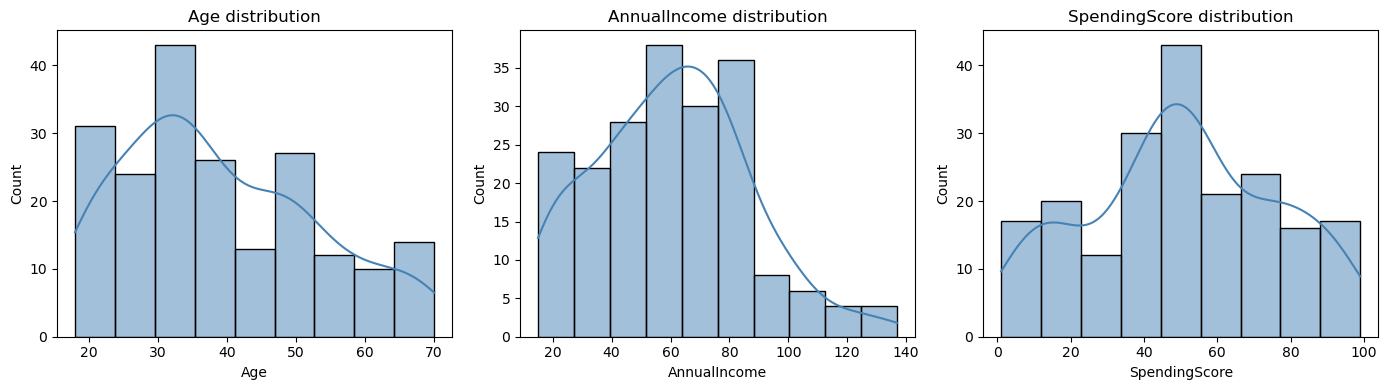

In [6]:
# Distribution of Age, Income, Spending Score
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age', 'AnnualIncome', 'SpendingScore']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()

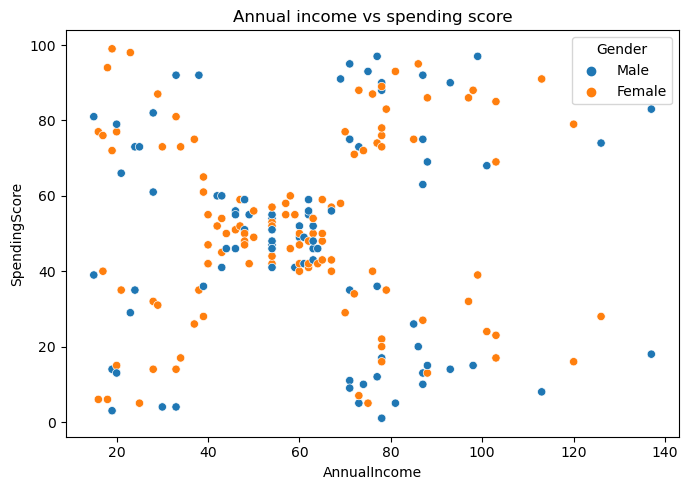

In [7]:
# Scatter: Income vs Spending Score
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore', hue='Gender')
plt.title('Annual income vs spending score')
plt.tight_layout()
plt.savefig('income_vs_spending.png')
plt.show()

# Preprocessing

In [8]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode Gender: Female=0, Male=1
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# Select features for clustering
# We use Income and SpendingScore as the primary pair (most meaningful business-wise)
# Then we'll do a second run with Age included
X = df[['AnnualIncome', 'SpendingScore']]

# Scale features so both are on the same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features ready for clustering:")
print(pd.DataFrame(X_scaled, columns=['AnnualIncome_scaled', 'SpendingScore_scaled']).head())

Features ready for clustering:
   AnnualIncome_scaled  SpendingScore_scaled
0            -1.738999             -0.434801
1            -1.738999              1.195704
2            -1.700830             -1.715913
3            -1.700830              1.040418
4            -1.662660             -0.395980


# Find the best K and train the model
# Part A - The Elbow method (finding the right number of clusters)

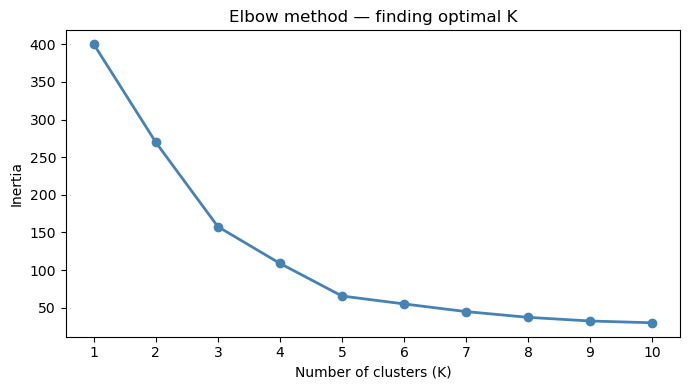

In [10]:
from sklearn.cluster import KMeans

# Try K values from 1 to 10 and record inertia (within-cluster sum of squares)
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    
# Plot the elbow curve
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow method — finding optimal K')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('elbow_curve.png')
plt.show()

# Part B - Train the final model with K=5

In [11]:
# Train with optimal K
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels back to the original dataframe
df['Cluster'] = kmeans.labels_

print(df['Cluster'].value_counts())
print(df.groupby('Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64
               Age  AnnualIncome  SpendingScore
Cluster                                        
0        42.716049     55.296296      49.518519
1        32.692308     86.538462      82.128205
2        25.272727     25.727273      79.363636
3        41.114286     88.200000      17.114286
4        45.217391     26.304348      20.913043


# Visualize and Interpret

Cluster Scatter plot

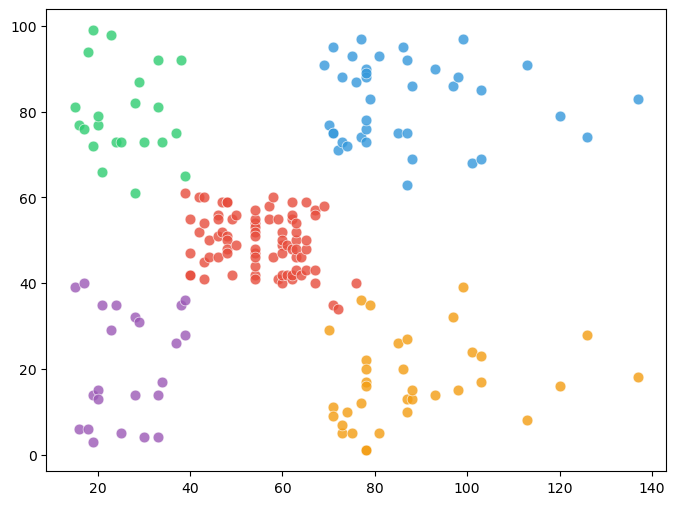

In [15]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(8, 6))
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['AnnualIncome'],
        cluster_data['SpendingScore'],
        label=f'Cluster {i}',
        color=colors[i],
        s=60, alpha=0.8, edgecolors='white', linewidth=0.5
    )


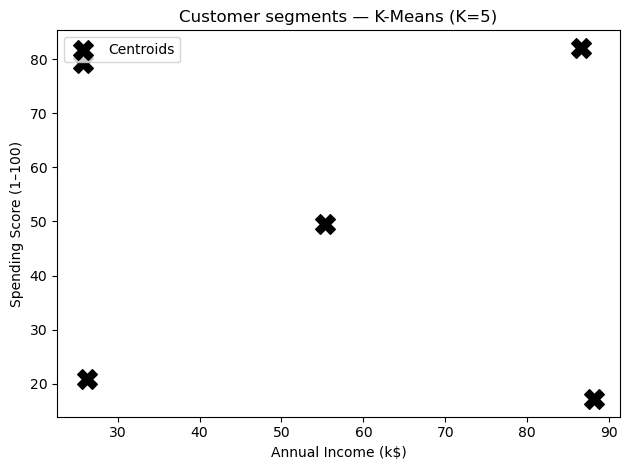

In [20]:
# Plot centroids (convert back from scaled to original scale)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=200, c='black', marker='X', label='Centroids', zorder=5
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.title('Customer segments — K-Means (K=5)')
plt.legend()
plt.tight_layout()
plt.savefig('customer_clusters.png')
plt.show()

Cluster profile summary

In [21]:
cluster_summary = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('AnnualIncome', 'mean'),
    Avg_Spending=('SpendingScore', 'mean')
).round(1)

print(cluster_summary)

         Count  Avg_Age  Avg_Income  Avg_Spending
Cluster                                          
0           81     42.7        55.3          49.5
1           39     32.7        86.5          82.1
2           22     25.3        25.7          79.4
3           35     41.1        88.2          17.1
4           23     45.2        26.3          20.9


Pairplot across all features

/Users/rheajose/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 700x500 with 0 Axes>

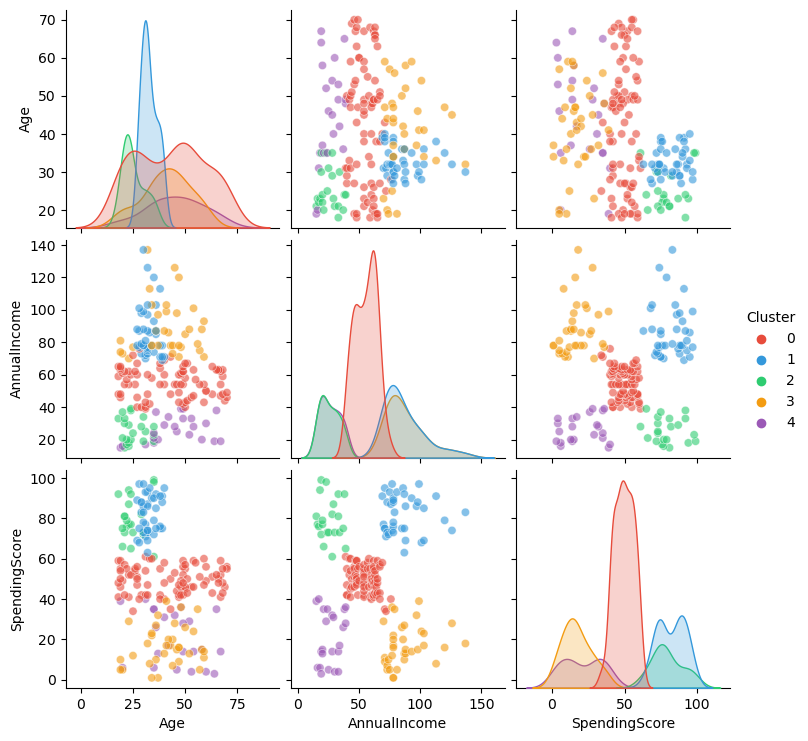

In [23]:
plt.figure(figsize=(7, 5))
sns.pairplot(df[['Age', 'AnnualIncome', 'SpendingScore', 'Cluster']],
             hue='Cluster', palette=colors, plot_kws={'alpha': 0.6})
plt.savefig('pairplot_clusters.png')
plt.show()